<a href="https://colab.research.google.com/github/ibrahim4606/Seasonal_Agriculture_Performance_Analysis_Ibrahim/blob/main/Seasonal_Agriculture_Performance_Ibrahim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seasonal Agriculture Performance Analysis
Major Project – VOIS AICTE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Original dataset filename — do not rename the file
file_name = "seasonal_agriculture_performance_dataset.csv"

try:
    data = pd.read_csv(file_name)
except FileNotFoundError:
    from google.colab import files
    uploaded = files.upload()
    if file_name in uploaded:
        data = pd.read_csv(file_name)
    else:
        uploaded_name = next(iter(uploaded))
        data = pd.read_csv(uploaded_name)

print("Dataset loaded successfully.")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
display(data.head())


Dataset loaded successfully.
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1. Understanding the Dataset


In [ ]:

print("Number of rows:", len(data))
print("Number of columns:", data.shape[1])
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame("Data Type"))

print("\nDuplicate rows:", data.duplicated().sum())


Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Duplicate rows: 0


## 2. Data Cleaning and Preparation


In [ ]:

# Missing-value check
missing = data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing):
    print("Columns with missing values:")
    display(missing.to_frame("Missing Values"))
else:
    print("No missing values found.")

print("Duplicate rows:", data.duplicated().sum())

# Make a working copy and clean it
df = data.copy()

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter cleaning:")
print("Remaining missing values:", int(df.isna().sum().sum()))
print("Remaining duplicate rows:", int(df.duplicated().sum()))


Columns with missing values:


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


Duplicate rows: 0

After cleaning:
Remaining missing values: 0
Remaining duplicate rows: 0


## 1. How does agricultural performance vary across different seasons?

,Season,Farms,Average_Yield,Total_Production,Average_Profit,Average_Water_Used
0,Kharif,1779,5.64,82387.61,178914.65,6102.20
1,Rabi,1627,5.08,67498.88,87689.47,5846.99
2,Zaid,594,4.67,23098.35,-24804.82,6419.89


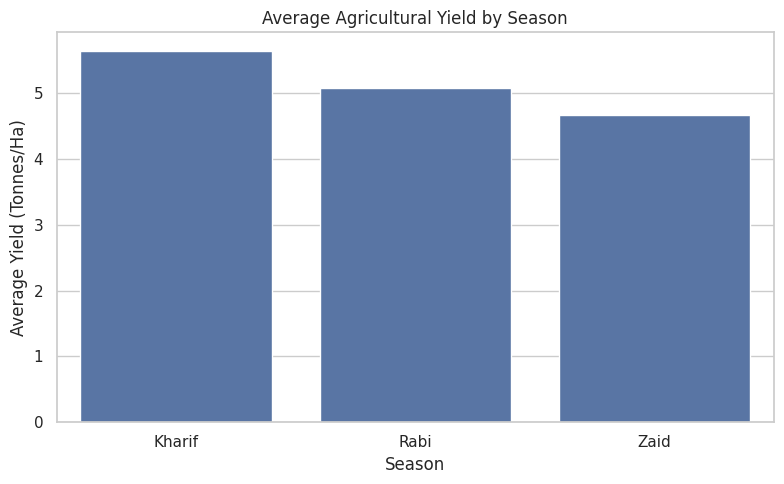

Solution: Kharif records the highest average yield of 5.64 tonnes/ha. Seasonal differences are also visible in production, profit and water usage.


In [ ]:
result = data.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).reset_index()

display(result.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=result, x="Season", y="Average_Yield")
plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

best = result.loc[result["Average_Yield"].idxmax()]
print(f"Solution: {best['Season']} records the highest average yield of {best['Average_Yield']:.2f} tonnes/ha. Seasonal differences are also visible in production, profit and water usage.")


## 2. What major seasonal patterns can be observed in crop production and yield?

,Season,Crop,Average_Yield,Total_Production
6,Kharif,Sugarcane,53.46,55759.37
3,Kharif,Maize,2.97,5463.54
5,Kharif,Rice,2.71,7049.19
7,Kharif,Wheat,2.26,5345.95
0,Kharif,Chilli,1.73,2675.74
2,Kharif,Groundnut,1.48,2024.62
1,Kharif,Cotton,1.37,2237.84
4,Kharif,Pulses,1.04,1831.36
14,Rabi,Sugarcane,43.94,47118.96
11,Rabi,Maize,2.61,5030.78


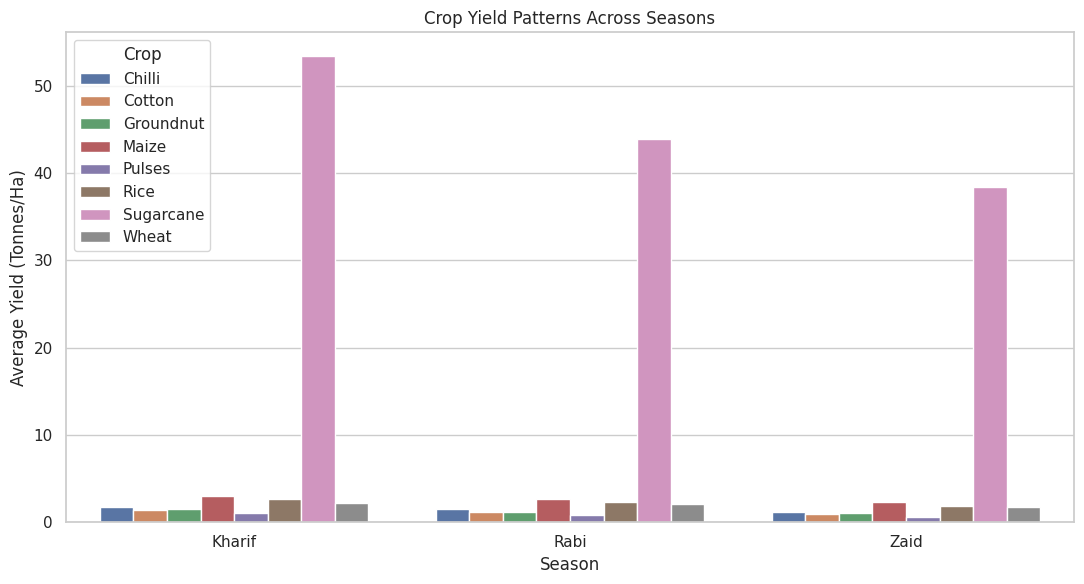

Solution: Crop performance changes across seasons. The comparison shows that crop yield and production are not uniform throughout the year, and some crop-season combinations perform better than others.


In [ ]:
result = data.groupby(["Season", "Crop"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum")
).reset_index()

display(result.sort_values(["Season", "Average_Yield"], ascending=[True, False]).round(2))

plt.figure(figsize=(11, 6))
sns.barplot(data=result, x="Season", y="Average_Yield", hue="Crop")
plt.title("Crop Yield Patterns Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print("Solution: Crop performance changes across seasons. The comparison shows that crop yield and production are not uniform throughout the year, and some crop-season combinations perform better than others.")


## 3. Which agricultural characteristics change significantly between seasons?

In [ ]:
columns = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Yield_Tonnes_Ha",
    "Production_Tonnes", "Water_Used_m3", "Profit_INR"
]

result = data.groupby("Season")[columns].mean().reset_index()
display(result.round(2))

# Relative change from overall average
comparison = result.copy()
for col in columns:
    overall = data[col].mean()
    comparison[col] = ((comparison[col] - overall) / overall * 100)

print("Percentage difference from the overall average:")
display(comparison.round(2))

print("Solution: Environmental conditions, soil moisture, nutrient inputs, water usage, yield and profit all vary between seasons. These differences indicate that agricultural conditions and requirements change with the season.")


,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Profit_INR
0,Kharif,7.94,852.08,28.45,71.81,6.79,31.20,120.02,58.10,105.30,187.08,5.08,5.64,46.31,6102.20,178914.65
1,Rabi,7.75,436.00,23.49,57.89,7.59,24.05,120.40,57.31,103.93,185.41,5.02,5.08,41.49,5846.99,87689.47
2,Zaid,8.09,299.42,31.04,52.01,8.18,19.17,120.53,58.13,105.42,184.64,5.17,4.67,38.89,6419.89,-24804.82


Percentage difference from the overall average:


,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Profit_INR
0,Kharif,0.72,41.74,6.10,13.61,-7.23,17.69,-0.19,0.54,0.52,0.56,0.17,7.08,7.09,0.94,60.38
1,Rabi,-1.72,-27.47,-12.42,-8.41,3.64,-9.27,0.13,-0.81,-0.80,-0.34,-0.91,-3.61,-4.07,-3.28,-21.39
2,Zaid,2.57,-50.19,15.75,-17.72,11.69,-27.68,0.23,0.60,0.63,-0.75,1.98,-11.47,-10.08,6.19,-122.24


Solution: Environmental conditions, soil moisture, nutrient inputs, water usage, yield and profit all vary between seasons. These differences indicate that agricultural conditions and requirements change with the season.


## 4. What differences can be seen in farming activities across different seasons?

In [ ]:
print("Crop mix:")
display(pd.crosstab(data["Season"], data["Crop"]))

print("Irrigation mix:")
display(pd.crosstab(data["Season"], data["Irrigation_Method"]))

activity = data.groupby("Season")[[
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3"
]].mean().reset_index()

display(activity.round(2))

print("Solution: Farming activities differ across seasons through crop selection, irrigation methods and the quantity of fertilizer, pesticide and water used. The differences show that farming practices are adjusted according to seasonal conditions and crop requirements.")


Crop mix:


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


Irrigation mix:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


,Season,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
0,Kharif,187.08,5.08,6102.20
1,Rabi,185.41,5.02,5846.99
2,Zaid,184.64,5.17,6419.89


Solution: Farming activities differ across seasons through crop selection, irrigation methods and the quantity of fertilizer, pesticide and water used. The differences show that farming practices are adjusted according to seasonal conditions and crop requirements.


## 5. Does resource usage, such as water, fertilizer, and pesticides, vary across seasons?

,Season,Average_Water,Average_Fertilizer,Average_Pesticide,Average_Water_Efficiency
0,Kharif,6102.20,187.08,5.08,5.89
1,Rabi,5846.99,185.41,5.02,5.19
2,Zaid,6419.89,184.64,5.17,4.41


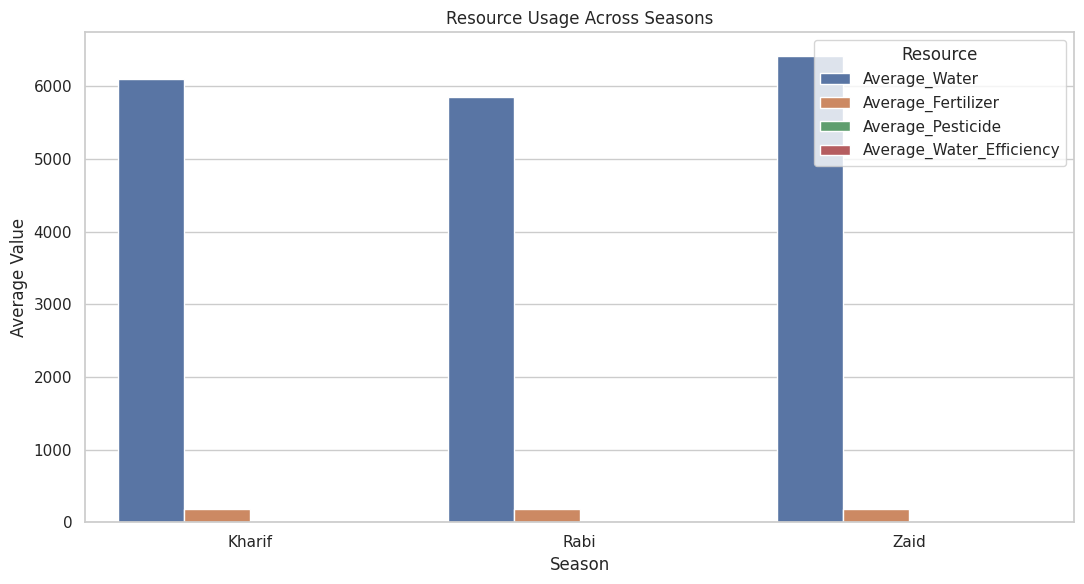

Solution: Resource usage varies across seasons. Water, fertilizer and pesticide requirements are different from one season to another, while water efficiency also changes. This can help in planning seasonal resource requirements.


In [ ]:
result = data.groupby("Season").agg(
    Average_Water=("Water_Used_m3", "mean"),
    Average_Fertilizer=("Fertilizer_kg_ha", "mean"),
    Average_Pesticide=("Pesticide_Litre_ha", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reset_index()

display(result.round(2))

plot_data = result.melt(
    id_vars="Season",
    var_name="Resource",
    value_name="Average_Value"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_data, x="Season", y="Average_Value", hue="Resource")
plt.title("Resource Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.tight_layout()
plt.show()

print("Solution: Resource usage varies across seasons. Water, fertilizer and pesticide requirements are different from one season to another, while water efficiency also changes. This can help in planning seasonal resource requirements.")


## 6. Are there relationships between seasonal environmental conditions and agricultural performance?

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Rainfall_mm,1.00,0.20,0.52,-0.36,0.02,0.52,0.03,0.02,0.11
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.03,0.08,0.01,0.01,0.01
Humidity_pct,0.52,0.14,1.00,-0.30,0.03,0.45,0.01,0.00,0.06
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,-0.02,-0.02,-0.05
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,-0.02,-0.01,-0.01
Soil_Moisture_pct,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.00,0.09
Yield_Tonnes_Ha,0.03,0.01,0.01,-0.02,-0.02,0.01,1.00,0.89,0.49
Production_Tonnes,0.02,0.01,0.00,-0.02,-0.01,0.00,0.89,1.00,0.55
Profit_INR,0.11,0.01,0.06,-0.05,-0.01,0.09,0.49,0.55,1.00


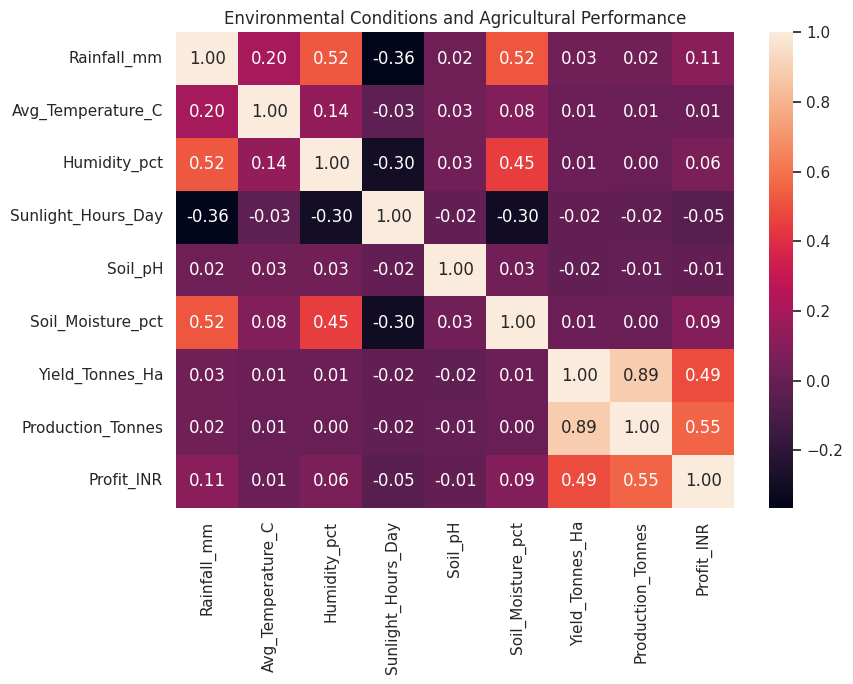

Correlation with yield:


,Correlation
Production_Tonnes,0.885
Profit_INR,0.490
Rainfall_mm,0.031
Humidity_pct,0.011
Soil_Moisture_pct,0.010
Avg_Temperature_C,0.009
Sunlight_Hours_Day,-0.015
Soil_pH,-0.021


Solution: Environmental variables such as rainfall, temperature, humidity, sunlight and soil moisture can be compared with yield and other performance measures through correlation. The results indicate associations in the dataset, not direct cause-and-effect relationships.


In [ ]:
columns = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
    "Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR"
]

corr = data[columns].corr()
display(corr.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Environmental Conditions and Agricultural Performance")
plt.tight_layout()
plt.show()

yield_corr = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(ascending=False)
print("Correlation with yield:")
display(yield_corr.to_frame("Correlation").round(3))

print("Solution: Environmental variables such as rainfall, temperature, humidity, sunlight and soil moisture can be compared with yield and other performance measures through correlation. The results indicate associations in the dataset, not direct cause-and-effect relationships.")


## 7. How do economic outcomes vary across seasons?

,Season,Average_Revenue,Average_Cost,Average_Profit
0,Kharif,710719.06,531804.41,178914.65
1,Rabi,601526.05,513836.58,87689.47
2,Zaid,519171.90,543976.73,-24804.82


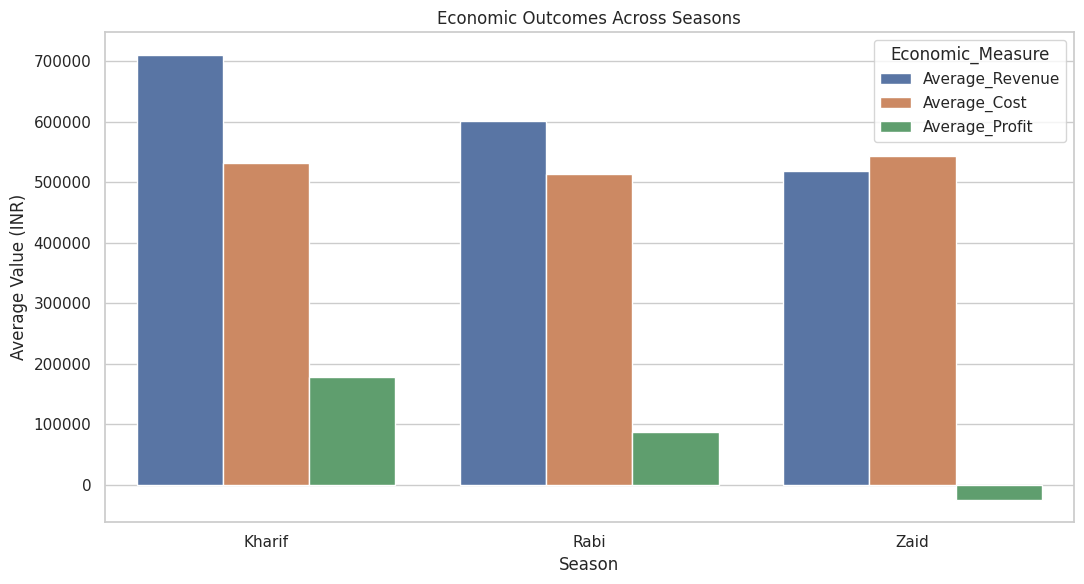

Solution: Kharif has the highest average profit of ₹178,914.65. Revenue and cost also differ across seasons, showing that seasonal conditions affect economic performance.


In [ ]:
result = data.groupby("Season").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

display(result.round(2))

plot_data = result.melt(
    id_vars="Season",
    var_name="Economic_Measure",
    value_name="Average_Value"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_data, x="Season", y="Average_Value", hue="Economic_Measure")
plt.title("Economic Outcomes Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value (INR)")
plt.tight_layout()
plt.show()

best_profit = result.loc[result["Average_Profit"].idxmax()]
print(f"Solution: {best_profit['Season']} has the highest average profit of ₹{best_profit['Average_Profit']:,.2f}. Revenue and cost also differ across seasons, showing that seasonal conditions affect economic performance.")


## 8. Are some seasonal patterns consistent across different regions or categories?

In [ ]:
crop_season = data.groupby(["Crop", "Season"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

print("Crop and season comparison:")
display(crop_season.round(2))

state_season = data.groupby(["State", "Season"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

print("State and season comparison:")
display(state_season.round(2))

print("Solution: Seasonal patterns are not necessarily identical across all crops and states. Comparing the same season within each crop and region helps identify whether a seasonal trend is consistent or mainly driven by particular categories.")


Crop and season comparison:


,Crop,Season,Average_Yield,Average_Profit
0,Chilli,Kharif,1.73,954380.42
1,Chilli,Rabi,1.46,638572.50
2,Chilli,Zaid,1.18,448659.09
3,Cotton,Kharif,1.37,216999.55
4,Cotton,Rabi,1.19,107343.59
5,Cotton,Zaid,0.95,-53925.34
6,Groundnut,Kharif,1.48,108265.44
7,Groundnut,Rabi,1.22,10416.54
8,Groundnut,Zaid,1.04,-68872.50
9,Maize,Kharif,2.97,-39332.67


State and season comparison:


,State,Season,Average_Yield,Average_Profit
0,Andhra Pradesh,Kharif,5.69,169315.52
1,Andhra Pradesh,Rabi,3.49,26315.71
2,Andhra Pradesh,Zaid,4.48,-84084.87
3,Gujarat,Kharif,6.34,217051.33
4,Gujarat,Rabi,5.52,82846.20
5,Gujarat,Zaid,4.10,-106929.61
6,Karnataka,Kharif,6.52,201226.21
7,Karnataka,Rabi,4.61,70952.61
8,Karnataka,Zaid,6.62,23310.91
9,Madhya Pradesh,Kharif,6.00,134242.40


Solution: Seasonal patterns are not necessarily identical across all crops and states. Comparing the same season within each crop and region helps identify whether a seasonal trend is consistent or mainly driven by particular categories.


## 9. Are there unusual or unexpected seasonal patterns?

Lower limit: -1.63
Upper limit: 5.52
Potential unusual yield records: 302


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,101.44,641.10,1608291,11781,60.1
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,1424.40,3330582,23289,42.7
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13,648.18,1471529,10705,59.9
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98,703.65,2216708,12787,44.5
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46,75.00,234320,1944,54.4
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,91.32,522.35,1236801,12199,50.6
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34,668.26,1984818,11547,36.9
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,87.76,672.24,2041678,12526,67.8
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,1249.21,3378879,23936,43.8
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79,534.58,1200815,11086,54.2


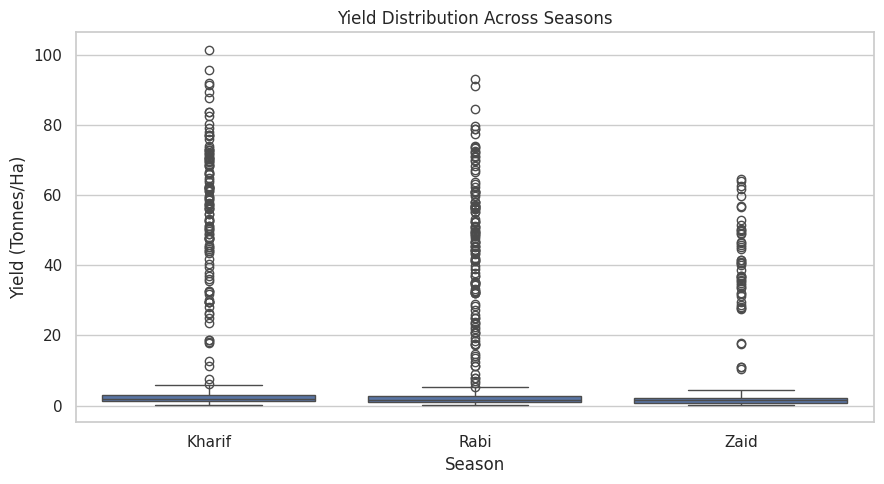

Solution: The IQR method identifies unusually high or low yield records. Such records may represent exceptional performance, unusual farm conditions or possible data-quality issues and should be investigated before being removed.


In [ ]:
q1 = data["Yield_Tonnes_Ha"].quantile(0.25)
q3 = data["Yield_Tonnes_Ha"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = data[
    (data["Yield_Tonnes_Ha"] < lower_limit) |
    (data["Yield_Tonnes_Ha"] > upper_limit)
]

print(f"Lower limit: {lower_limit:.2f}")
print(f"Upper limit: {upper_limit:.2f}")
print(f"Potential unusual yield records: {len(outliers)}")

display(outliers[[
    "Farm_ID", "State", "District", "Crop", "Season",
    "Yield_Tonnes_Ha", "Production_Tonnes",
    "Profit_INR", "Water_Used_m3", "Disease_Pest_Risk_pct"
]].sort_values("Yield_Tonnes_Ha", ascending=False).head(20))

plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print("Solution: The IQR method identifies unusually high or low yield records. Such records may represent exceptional performance, unusual farm conditions or possible data-quality issues and should be investigated before being removed.")


## 10. What insights can be derived from the observed seasonal differences?

In [ ]:
result = data.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reset_index()

display(result.round(2))

yield_best = result.loc[result["Average_Yield"].idxmax()]
profit_best = result.loc[result["Average_Profit"].idxmax()]
eff_best = result.loc[result["Average_Water_Efficiency"].idxmax()]

print(f"Solution: {yield_best['Season']} has the highest average yield ({yield_best['Average_Yield']:.2f} tonnes/ha).")
print(f"{profit_best['Season']} has the highest average profit (₹{profit_best['Average_Profit']:,.2f}).")
print(f"{eff_best['Season']} has the highest average water efficiency ({eff_best['Average_Water_Efficiency']:.2f} tonnes per 1000 m³).")
print("These comparisons show that the strongest season for yield, profit and water efficiency may not be the same.")


,Season,Average_Yield,Total_Production,Average_Profit,Average_Water_Used,Average_Water_Efficiency
0,Kharif,5.64,82387.61,178914.65,6102.20,5.89
1,Rabi,5.08,67498.88,87689.47,5846.99,5.19
2,Zaid,4.67,23098.35,-24804.82,6419.89,4.41


Solution: Kharif has the highest average yield (5.64 tonnes/ha).
Kharif has the highest average profit (₹178,914.65).
Kharif has the highest average water efficiency (5.89 tonnes per 1000 m³).
These comparisons show that the strongest season for yield, profit and water efficiency may not be the same.


## 11. What conclusions can reasonably be drawn from the available data?

In [ ]:
result = data.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

display(result.round(2))

print("Solution:")
print("1. Agricultural performance varies across seasons.")
print("2. Crop yield and production show seasonal differences.")
print("3. Resource requirements such as water, fertilizer and pesticide usage vary by season.")
print("4. Environmental conditions are associated with differences in agricultural performance.")
print("5. Revenue, cost and profit also change across seasons.")
print("6. Crop and regional comparisons show that seasonal performance is not uniform.")
print("7. The conclusions describe observed patterns in the dataset and should not be interpreted as proof of causation.")


,Season,Average_Yield,Total_Production,Average_Revenue,Average_Cost,Average_Profit
0,Kharif,5.64,82387.61,710719.06,531804.41,178914.65
1,Rabi,5.08,67498.88,601526.05,513836.58,87689.47
2,Zaid,4.67,23098.35,519171.90,543976.73,-24804.82


Solution:
1. Agricultural performance varies across seasons.
2. Crop yield and production show seasonal differences.
3. Resource requirements such as water, fertilizer and pesticide usage vary by season.
4. Environmental conditions are associated with differences in agricultural performance.
5. Revenue, cost and profit also change across seasons.
6. Crop and regional comparisons show that seasonal performance is not uniform.
7. The conclusions describe observed patterns in the dataset and should not be interpreted as proof of causation.


## 12. How could the findings support better seasonal agricultural planning?

In [ ]:
planning = data.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water=("Water_Used_m3", "mean"),
    Average_Fertilizer=("Fertilizer_kg_ha", "mean"),
    Average_Pesticide=("Pesticide_Litre_ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).reset_index()

display(planning.round(2))

print("Solution:")
print("• Use seasonal yield and profit results when selecting crops.")
print("• Plan irrigation according to seasonal water requirements and water efficiency.")
print("• Review fertilizer and pesticide usage against yield and risk levels.")
print("• Use crop- and region-specific strategies instead of one common approach.")
print("• Give additional attention to seasons with lower observed yield or profitability.")
print("• Combine historical seasonal patterns with current weather, soil and field conditions.")


,Season,Average_Yield,Average_Water,Average_Fertilizer,Average_Pesticide,Average_Profit,Average_Risk
0,Kharif,5.64,6102.20,187.08,5.08,178914.65,54.47
1,Rabi,5.08,5846.99,185.41,5.02,87689.47,40.48
2,Zaid,4.67,6419.89,184.64,5.17,-24804.82,38.22


Solution:
• Use seasonal yield and profit results when selecting crops.
• Plan irrigation according to seasonal water requirements and water efficiency.
• Review fertilizer and pesticide usage against yield and risk levels.
• Use crop- and region-specific strategies instead of one common approach.
• Give additional attention to seasons with lower observed yield or profitability.
• Combine historical seasonal patterns with current weather, soil and field conditions.


## 13. Which irrigation methods appear to be associated with better crop yield across different seasons?

,Season,Irrigation_Method,Farms,Average_Yield,Average_Water_Used,Average_Water_Efficiency,Average_Profit
0,Kharif,Drip,405,7.26,5953.37,6.80,317222.07
2,Kharif,Rainfed,463,5.72,3687.52,8.85,158974.13
1,Kharif,Flood,590,5.00,8229.27,3.64,133373.83
3,Kharif,Sprinkler,321,4.67,5863.27,4.62,116880.49
4,Rabi,Drip,370,6.21,5911.41,6.05,187843.22
7,Rabi,Sprinkler,293,5.36,6129.09,4.64,76502.07
5,Rabi,Flood,526,5.10,7766.83,3.48,58824.80
6,Rabi,Rainfed,438,3.94,3298.29,6.87,45232.48
11,Zaid,Sprinkler,120,6.17,7324.41,4.86,57909.40
8,Zaid,Drip,140,5.85,5837.99,5.30,21291.84


Highest observed average-yield irrigation method for each season:


,Season,Irrigation_Method,Farms,Average_Yield,Average_Water_Used,Average_Water_Efficiency,Average_Profit
0,Kharif,Drip,405,7.26,5953.37,6.80,317222.07
1,Rabi,Drip,370,6.21,5911.41,6.05,187843.22
2,Zaid,Sprinkler,120,6.17,7324.41,4.86,57909.40


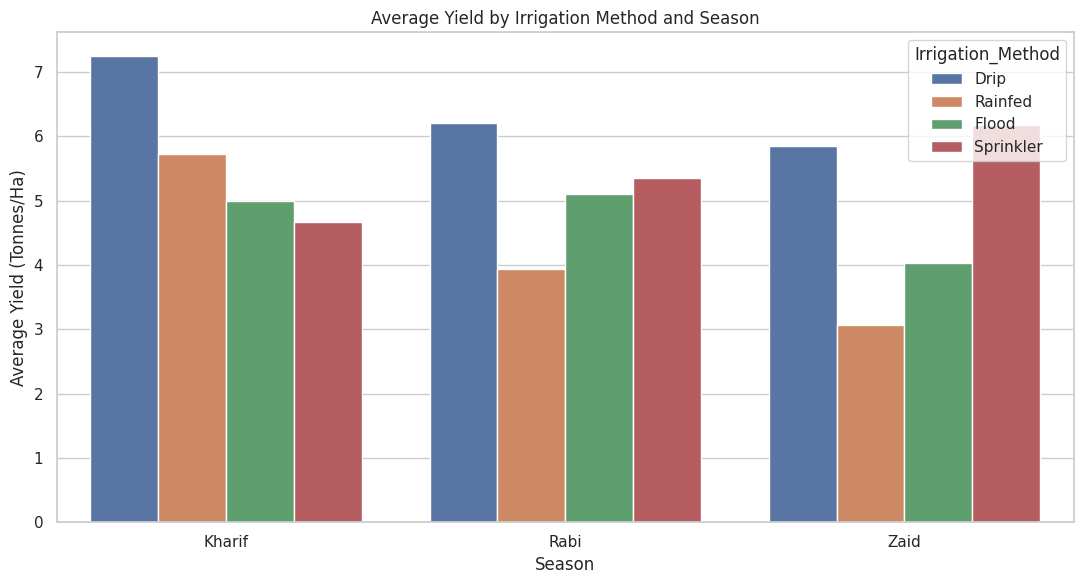

Solution: Irrigation methods show different average yield levels across seasons. The method with the highest observed yield in each season is listed above. Other factors such as crop, region and environmental conditions should also be considered.


In [ ]:
result = data.groupby(["Season", "Irrigation_Method"]).agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

result = result.sort_values(
    ["Season", "Average_Yield"],
    ascending=[True, False]
)

display(result.round(2))

best = result.loc[
    result.groupby("Season")["Average_Yield"].idxmax()
].reset_index(drop=True)

print("Highest observed average-yield irrigation method for each season:")
display(best.round(2))

plt.figure(figsize=(11, 6))
sns.barplot(
    data=result,
    x="Season",
    y="Average_Yield",
    hue="Irrigation_Method"
)
plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print("Solution: Irrigation methods show different average yield levels across seasons. The method with the highest observed yield in each season is listed above. Other factors such as crop, region and environmental conditions should also be considered.")


## 14. Which crops show the most consistent performance across different seasons and regions?

,Crop,Number_of_Records,Seasons,Average_Yield,Yield_Std,Minimum_Yield,Maximum_Yield,Average_Profit,Yield_CV_Percent
1,Cotton,508,3,1.23,0.53,0.30,2.90,124546.92,42.85
7,Wheat,614,3,2.11,0.91,0.30,4.56,-123398.34,43.38
6,Sugarcane,305,3,46.94,21.09,1.39,101.44,817187.99,44.93
3,Maize,551,3,2.72,1.24,0.30,6.08,-83978.33,45.51
2,Groundnut,424,3,1.32,0.61,0.30,3.02,44858.12,46.12
4,Pulses,496,3,0.92,0.42,0.30,2.09,-4238.05,46.19
5,Rice,690,3,2.44,1.15,0.30,5.70,-102213.50,47.06
0,Chilli,412,3,1.54,0.79,0.30,3.90,750878.34,51.00


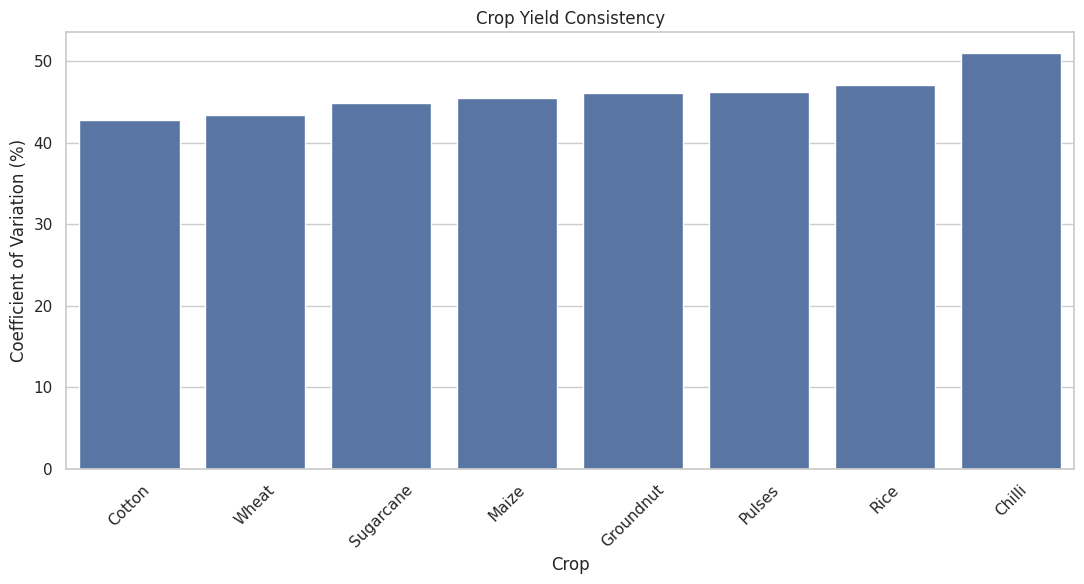

Solution: Cotton has the lowest yield coefficient of variation (42.85%), so it shows the most consistent yield relative to its average in this dataset.
A lower coefficient of variation indicates greater relative stability. The number of observations and seasonal/region coverage should also be considered.


In [ ]:
result = data.groupby("Crop").agg(
    Number_of_Records=("Farm_ID", "count"),
    Seasons=("Season", "nunique"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Yield_Std=("Yield_Tonnes_Ha", "std"),
    Minimum_Yield=("Yield_Tonnes_Ha", "min"),
    Maximum_Yield=("Yield_Tonnes_Ha", "max"),
    Average_Profit=("Profit_INR", "mean")
).reset_index()

result["Yield_CV_Percent"] = (
    result["Yield_Std"] / result["Average_Yield"] * 100
)

result = result.sort_values("Yield_CV_Percent")

display(result.round(2))

plt.figure(figsize=(11, 6))
sns.barplot(data=result, x="Crop", y="Yield_CV_Percent")
plt.title("Crop Yield Consistency")
plt.xlabel("Crop")
plt.ylabel("Coefficient of Variation (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

most_consistent = result.iloc[0]

print(f"Solution: {most_consistent['Crop']} has the lowest yield coefficient of variation ({most_consistent['Yield_CV_Percent']:.2f}%), so it shows the most consistent yield relative to its average in this dataset.")
print("A lower coefficient of variation indicates greater relative stability. The number of observations and seasonal/region coverage should also be considered.")
